In [227]:
import pandas as pd

In [228]:
df = pd.read_csv('dataset.csv')


In [229]:
df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)'],
      dtype='object')

# Gausian Noise

In [230]:
import pandas as pd
import numpy as np

def augment_data_vectorized(df, n_synthetic=10):
    """
    Expands the dataset by generating synthetic samples using Gaussian noise.
    
    Args:
        df: The original DataFrame.
        n_synthetic: Number of synthetic points to generate per original row.
    """
    # 1. Repeat each row n_synthetic times
    df_aug = df.loc[df.index.repeat(n_synthetic)].reset_index(drop=True)
    
    # 2. Generate Gaussian noise: Mean = 0, SD = 1
    # We multiply this by the actual SD from the table to scale the noise
    noise = np.random.normal(size=len(df_aug))
    
    # 3. Apply the noise: New Value = Mean + (Noise * SD)
    df_aug['Tensile Stress (Augmented)'] = (
        df_aug['Mean Tensile Stress (MPa)'] + 
        (noise * df_aug['Tensile Stress SD (MPa)'])
    ).round(3)
    
    # 4. Shuffle the dataset so the model doesn't learn the order of experiments
    return df_aug.sample(frac=1).reset_index(drop=True)

# Execute the augmentation
# If you have 33 rows, this will result in 99 rows
augmented_df = augment_data_vectorized(df, n_synthetic=3)

# Display a preview
print(f"Dataset expanded from {len(df)} to {len(augmented_df)} rows.")
print(augmented_df[['Infill Pattern', 'Mean Tensile Stress (MPa)', 'Tensile Stress (Augmented)']].head())

Dataset expanded from 33 to 99 rows.
  Infill Pattern  Mean Tensile Stress (MPa)  Tensile Stress (Augmented)
0  Triangle-Hexa                      14.16                      13.924
1           Grid                      13.94                      14.217
2           Grid                       8.42                       7.793
3  Triangle-Hexa                      14.44                      14.585
4  Triangle-Hexa                      11.08                      11.213


In [231]:
augmented_df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)'],
      dtype='object')

In [232]:
augmented_df

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,33,16,60.00,240.00,Triangle-Hexa,14.16,0.48,13.924
1,11,6,60.00,240.00,Grid,13.94,0.36,14.217
2,1,14,45.86,225.86,Grid,8.42,0.31,7.793
3,30,1,60.00,260.00,Triangle-Hexa,14.44,0.52,14.585
4,23,5,45.87,225.86,Triangle-Hexa,11.08,0.29,11.213
...,...,...,...,...,...,...,...,...
94,31,10,60.00,240.00,Triangle-Hexa,12.64,0.43,11.936
95,8,32,60.00,260.00,Grid,17.76,0.75,17.790
96,21,3,60.00,240.00,Triangle,12.68,0.42,12.660
97,32,15,60.00,240.00,Triangle-Hexa,14.51,0.57,14.567


In [233]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(augmented_df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [234]:
df_encoded[['Infill Pattern_Grid', 'Infill Pattern_Triangle', 'Infill Pattern_Triangle-Hexa']].head(3)

,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa
0,0,0,1
1,1,0,0
2,1,0,0


# baseline corrilation

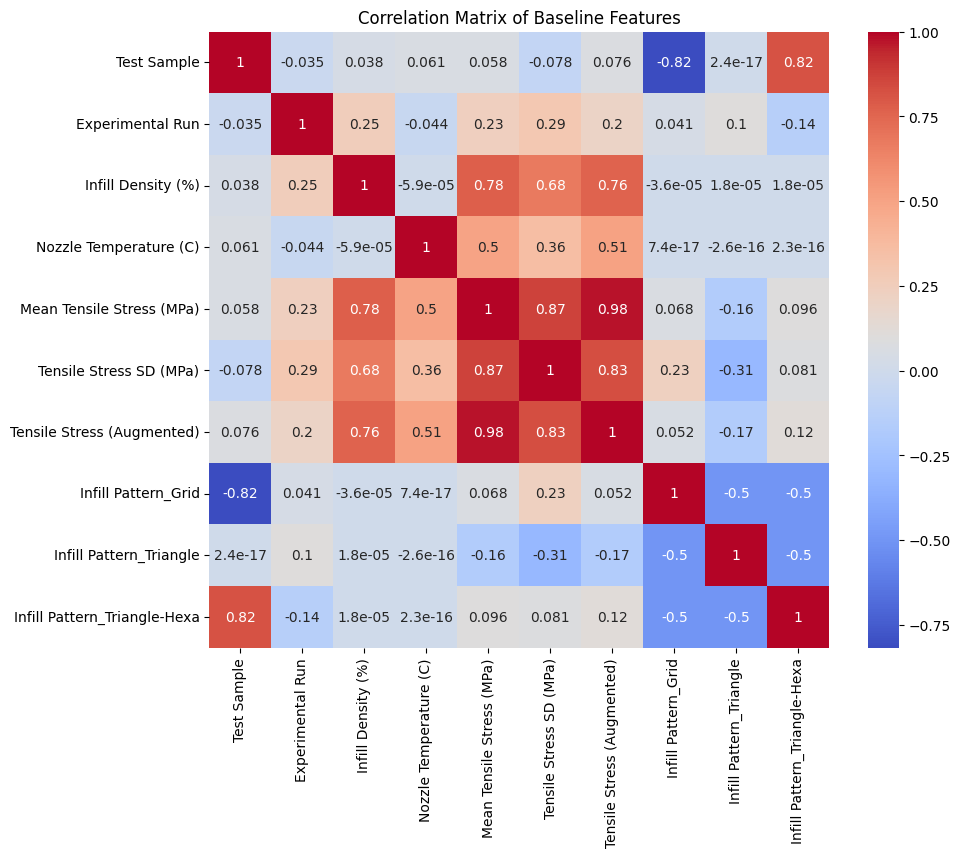

In [235]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Baseline Features')
plt.show()

In [236]:
df_encoded.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)',
       'Infill Pattern_Grid', 'Infill Pattern_Triangle',
       'Infill Pattern_Triangle-Hexa'],
      dtype='object')

## Effective Area ($A_{eff}$)

In [237]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

In [238]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff)
0,33,16,60.00,240.00,14.16,0.48,13.924,0,0,1,60.000
1,11,6,60.00,240.00,13.94,0.36,14.217,1,0,0,42.000
2,1,14,45.86,225.86,8.42,0.31,7.793,1,0,0,32.102
3,30,1,60.00,260.00,14.44,0.52,14.585,0,0,1,60.000
4,23,5,45.87,225.86,11.08,0.29,11.213,0,0,1,45.870
...,...,...,...,...,...,...,...,...,...,...,...
94,31,10,60.00,240.00,12.64,0.43,11.936,0,0,1,60.000
95,8,32,60.00,260.00,17.76,0.75,17.790,1,0,0,42.000
96,21,3,60.00,240.00,12.68,0.42,12.660,0,1,0,51.000
97,32,15,60.00,240.00,14.51,0.57,14.567,0,0,1,60.000


## polymer difusin rate

In [239]:
# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [240]:
df_encoded[['Mean Tensile Stress (MPa)','Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)']]

,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,14.16,0.48,13.924
1,13.94,0.36,14.217
2,8.42,0.31,7.793
3,14.44,0.52,14.585
4,11.08,0.29,11.213
...,...,...,...
94,12.64,0.43,11.936
95,17.76,0.75,17.790
96,12.68,0.42,12.660
97,14.51,0.57,14.567


# physics augmented corrilation

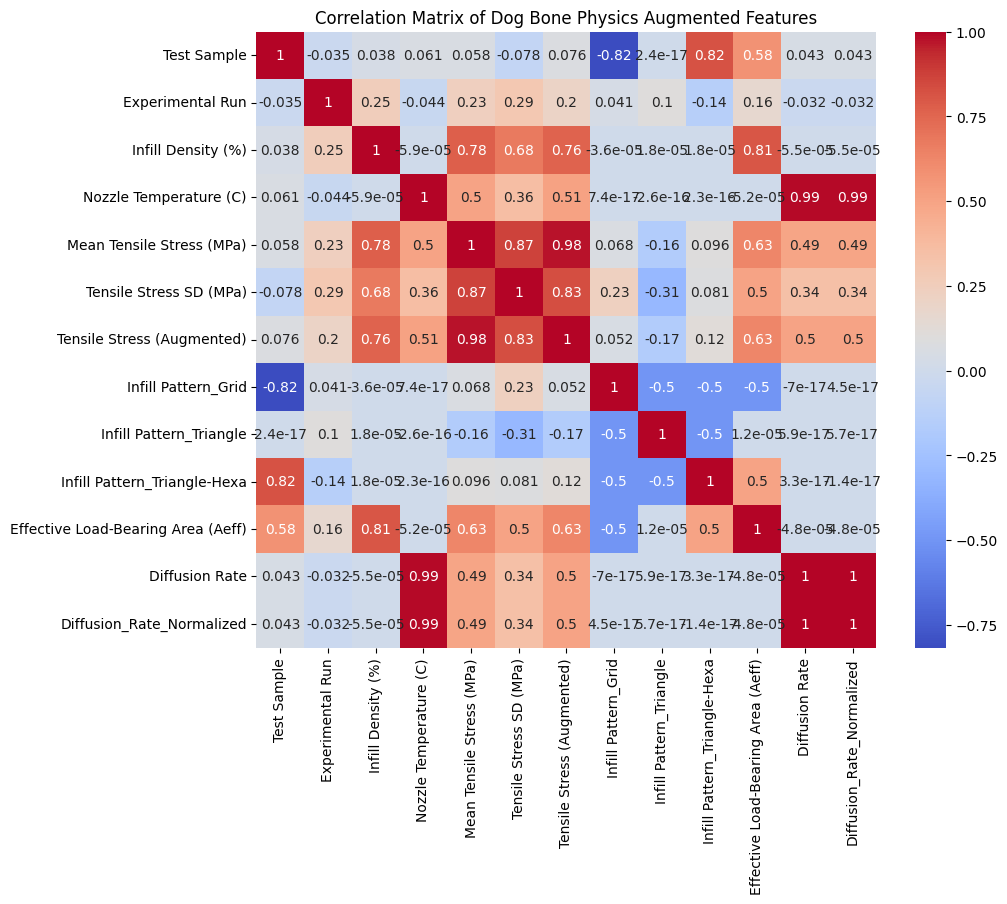

In [241]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Dog Bone Physics Augmented Features')
plt.show()

In [242]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,33,16,60.00,240.00,14.16,0.48,13.924,0,0,1,60.000,1.196421e-07,0.367799
1,11,6,60.00,240.00,13.94,0.36,14.217,1,0,0,42.000,1.196421e-07,0.367799
2,1,14,45.86,225.86,8.42,0.31,7.793,1,0,0,32.102,7.616198e-08,0.087035
3,30,1,60.00,260.00,14.44,0.52,14.585,0,0,1,60.000,2.175468e-07,1.000000
4,23,5,45.87,225.86,11.08,0.29,11.213,0,0,1,45.870,7.616198e-08,0.087035
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,31,10,60.00,240.00,12.64,0.43,11.936,0,0,1,60.000,1.196421e-07,0.367799
95,8,32,60.00,260.00,17.76,0.75,17.790,1,0,0,42.000,2.175468e-07,1.000000
96,21,3,60.00,240.00,12.68,0.42,12.660,0,1,0,51.000,1.196421e-07,0.367799
97,32,15,60.00,240.00,14.51,0.57,14.567,0,0,1,60.000,1.196421e-07,0.367799


# Features defination

In [243]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    'Infill Density (%)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)', 
    'Diffusion_Rate_Normalized'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target_augmented = 'Tensile Stress (Augmented)'
target_validation = 'Mean Tensile Stress (MPa)'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [245]:
y_test.describe()

count    20.000000
mean     13.128550
std       3.118064
min       9.171000
25%      10.768500
50%      11.976500
75%      16.324000
max      18.134000
Name: Tensile Stress (Augmented), dtype: float64

# RF baseline

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_base, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)
print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} MPa")
print(f"MSE         : {rf_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {rf_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_base = cross_val_score(rf_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {rf_cv_r2_base.mean():.4f}  (±{rf_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_base, 4)}")

rf_cv_r2_base = rf_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest Prediction (Test) for BaseLine Features ===
R²          : 0.9053
RMSE        : 0.935 MPa
MSE         : 0.8751 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 10.00%
  Engineering    (±0.50 MPa): 25.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.8729  (±0.0357)
Scores  : [0.9088 0.8998 0.8774 0.8071 0.8714]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.591427
      Nozzle Temperature (C)    0.326201
     Infill Pattern_Triangle    0.032425
         Infill Pattern_Grid    0.027082
Infill Pattern_Triangle-Hexa    0.022865


# rf physics

In [247]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [248]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train_physics, y_train)

y_pred = rf_physics.predict(X_test)

rf_r2_physics  = r2_score(y_test, y_pred)
rf_mse_physics = mean_squared_error(y_test, y_pred)
rf_rmse_physics = np.sqrt(rf_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {rf_r2_physics:.4f}")
print(f"RMSE        : {rf_rmse_physics:.3f} MPa")
print(f"MSE         : {rf_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { rf_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_physics = cross_val_score(rf_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {rf_cv_r2_physics.mean():.4f}  (±{rf_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_physics, 4)}")

rf_cv_r2_physics = rf_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Random Forest Prediction (Test) for Physics Augmented Features ===
R²          : 0.9068
RMSE        : 0.928 MPa
MSE         : 0.8611 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 20.00%
  Engineering    (±0.50 MPa): 25.00%
  Acceptable     (±1.00 MPa): 60.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.8498  (±0.0631)
Scores  : [0.9098 0.9074 0.8654 0.7393 0.8271]

=== Feature Importances (Top 10) ===
                           feature  importance
                Infill Density (%)    0.335817
Effective Load-Bearing Area (Aeff)    0.331925
         Diffusion_Rate_Normalized    0.264769
           Infill Pattern_Triangle    0.025768
               Infill Pattern_Grid    0.025733
      Infill Pattern_Triangle-Hexa    0.015989


In [249]:
rf_cv_r2_physics

np.float64(0.8498056688403588)

In [250]:
print("======== Random Forest =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {rf_r2_base:.4f}   | Physics-Augmented R²: {rf_r2_physics:.4f}")
print(f"Baseline CV R²: {rf_cv_r2_base:.4f}| Physics-Augmented CV R²: {rf_cv_r2_physics:.4f}")
print(f"Baseline mse: {rf_mse_base: .4f} | Physics-Augmented mse: {rf_mse_physics:.4f}")
print(f"Baseline rmse: {rf_rmse_base: .4f}| Physics-Augmented rmse: {rf_rmse_physics:.4f}")

======== Random Forest =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.9053   | Physics-Augmented R²: 0.9068
Baseline CV R²: 0.8729| Physics-Augmented CV R²: 0.8498
Baseline mse:  0.8751 | Physics-Augmented mse: 0.8611
Baseline rmse:  0.9355| Physics-Augmented rmse: 0.9279


# XGBoost baseline


In [251]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train_base, y_train)

y_pred = xgb_base.predict(X_test)

xgb_r2_base  = r2_score(y_test, y_pred)
xgb_mse_base = mean_squared_error(y_test, y_pred)
xgb_rmse_base = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
xgb_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for BaseLine Features ===")
print(f"R²          : {xgb_r2_base:.4f}")
print(f"RMSE        : {xgb_rmse_base:.3f} MPa")
print(f"MSE         : {xgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_base = cross_val_score(xgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {xgb_cv_r2_base.mean():.4f}  (±{xgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_base, 4)}")

xgb_cv_r2_base = xgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': xgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for BaseLine Features ===
R²          : 0.9053
RMSE        : 0.935 MPa
MSE         : 0.8751 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 10.00%
  Engineering    (±0.50 MPa): 25.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.8729  (±0.0357)
Scores  : [0.9088 0.8998 0.8774 0.8071 0.8714]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.591427
      Nozzle Temperature (C)    0.326201
     Infill Pattern_Triangle    0.032425
         Infill Pattern_Grid    0.027082
Infill Pattern_Triangle-Hexa    0.022865


# XGBoost Physics

In [253]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_physics.fit(X_train_physics, y_train)

y_pred = xgb_physics.predict(X_test)

xgb_r2_physics  = r2_score(y_test, y_pred)
xgb_mse_physics = mean_squared_error(y_test, y_pred)
xgb_rmse_physics = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

xgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {xgb_r2_physics:.4f}")
print(f"RMSE        : {xgb_rmse_physics:.3f} MPa")
print(f"MSE         : {xgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_physics = cross_val_score(xgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {xgb_cv_r2_physics.mean():.4f}  (±{xgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_physics, 4)}")

xgb_cv_r2_physics = xgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': xgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for Physics Augmented Features ===
R²          : 0.9068
RMSE        : 0.935 MPa
MSE         : 0.8611 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 20.00%
  Engineering    (±0.50 MPa): 25.00%
  Acceptable     (±1.00 MPa): 60.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.8498  (±0.0631)
Scores  : [0.9098 0.9074 0.8654 0.7393 0.8271]

=== Feature Importances (Top 10) ===
                           feature  importance
                Infill Density (%)    0.335817
Effective Load-Bearing Area (Aeff)    0.331925
         Diffusion_Rate_Normalized    0.264769
           Infill Pattern_Triangle    0.025768
               Infill Pattern_Grid    0.025733
      Infill Pattern_Triangle-Hexa    0.015989


In [255]:
print("======== Xgboost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {xgb_r2_base:.4f}   | Physics-Augmented R²: {xgb_r2_physics:.4f}")
print(f"Baseline CV R²: {xgb_cv_r2_base:.4f}   | Physics-Augmented CV R²: {xgb_cv_r2_physics:.4f}")
print(f"Baseline mse: {xgb_mse_base: .4f} | Physics-Augmented mse: {xgb_mse_physics:.4f}")
print(f"Baseline rmse: {xgb_rmse_base: .4f}| Physics-Augmented rmse: {xgb_rmse_physics:.4f}")

======== Xgboost =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.9053   | Physics-Augmented R²: 0.9068
Baseline CV R²: 0.8729   | Physics-Augmented CV R²: 0.8498
Baseline mse:  0.8751 | Physics-Augmented mse: 0.8611
Baseline rmse:  0.9355| Physics-Augmented rmse: 0.9355


# LightGBM base

In [256]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [257]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_base = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42,
    verbosity=-1 
)

lgb_base.fit(X_train_base, y_train)

y_pred = lgb_base.predict(X_test)

lgb_r2_base  = r2_score(y_test, y_pred)
lgb_mse_base = mean_squared_error(y_test, y_pred)
lgb_rmse_base = np.sqrt(lgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for BaseLine Features ===")
print(f"R²          : {lgb_r2_base:.4f}")
print(f"RMSE        : {lgb_rmse_base:.3f} MPa")
print(f"MSE         : {lgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {lgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
lgb_cv_r2_base = cross_val_score(lgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {lgb_cv_r2_base.mean():.4f}  (±{lgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_base, 4)}")

lgb_cv_r2_base = lgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': lgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for BaseLine Features ===
R²          : 0.7521
RMSE        : 1.513 MPa
MSE         : 2.2896 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 15.00%
  Engineering    (±0.50 MPa): 20.00%
  Acceptable     (±1.00 MPa): 45.00%
  Upper Bound    (±2.00 MPa): 90.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.6710  (±0.1719)
Scores  : [0.7521 0.7487 0.7204 0.3312 0.8024]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)         619
      Nozzle Temperature (C)         332
     Infill Pattern_Triangle          18
Infill Pattern_Triangle-Hexa          17
         Infill Pattern_Grid          14


# LGB physics

In [258]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [259]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_physics = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42
)

lgb_physics.fit(X_train_physics, y_train)

y_pred = lgb_physics.predict(X_test)

lgb_r2_physics  = r2_score(y_test, y_pred)
lgb_mse_physics = mean_squared_error(y_test, y_pred)
lgb_rmse_physics = np.sqrt(lgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for Physics augmented Features ===")
print(f"R²          : {lgb_r2_physics:.4f}")
print(f"RMSE        : {lgb_rmse_physics:.3f} MPa")
print(f"MSE         : {lgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { lgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
lgb_cv_r2_physics = cross_val_score(lgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {lgb_cv_r2_physics.mean():.4f}  (±{lgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_physics, 4)}")

lgb_cv_r2_physics = lgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': lgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for Physics augmented Features ===
R²          : 0.7800
RMSE        : 1.425 MPa
MSE         : 2.0320 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 10.00%
  Engineering    (±0.50 MPa): 20.00%
  Acceptable     (±1.00 MPa): 60.00%
  Upper Bound    (±2.00 MPa): 85.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.6444  (±0.2283)
Scores  : [0.78   0.7524 0.6819 0.1959 0.8118]

=== Feature Importances (Top 10) ===
                           feature  importance
                Infill Density (%)         605
         Diffusion_Rate_Normalized         251
Effective Load-Bearing Area (Aeff)         125
           Infill Pattern_Triangle          15
               Infill Pattern_Grid           2
      Infill Pattern_Triangle-Hexa           0


In [260]:
print("======== LightGBM =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {lgb_r2_base:.4f}   | Physics-Augmented R²: {lgb_r2_physics:.4f}")
print(f"Baseline CV R²: {lgb_cv_r2_base:.4f}| Physics-Augmented CV R²: {lgb_cv_r2_physics:.4f}")
print(f"Baseline mse: {lgb_mse_base: .4f} | Physics-Augmented mse: {lgb_mse_physics:.4f}")
print(f"Baseline rmse: {lgb_rmse_base: .4f}| Physics-Augmented rmse: {lgb_rmse_physics:.4f}")

======== LightGBM =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.7521   | Physics-Augmented R²: 0.7800
Baseline CV R²: 0.6710| Physics-Augmented CV R²: 0.6444
Baseline mse:  2.2896 | Physics-Augmented mse: 2.0320
Baseline rmse:  1.5131| Physics-Augmented rmse: 1.4255


# catboost base

In [261]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [262]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_base = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_base.fit(X_train_base, y_train)

y_pred = cat_base.predict(X_test)

cat_r2_base  = r2_score(y_test, y_pred)
cat_mse_base = mean_squared_error(y_test, y_pred)
cat_rmse_base = np.sqrt(cat_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
cat_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Baseline  ===")
print(f"R²          : {cat_r2_base:.4f}")
print(f"RMSE        : {cat_rmse_base:.3f} MPa")
print(f"MSE         : {cat_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_base tscv object
cat_cv_r2_base = cross_val_score(cat_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {cat_cv_r2_base.mean():.4f}  (±{cat_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_base, 4)}")

cat_cv_r2_base = cat_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': cat_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Baseline  ===
R²          : 0.9307
RMSE        : 0.800 MPa
MSE         : 0.6401 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 65.00%
  Acceptable     (±1.00 MPa): 75.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.9227  (±0.0167)
Scores  : [0.9309 0.9384 0.9197 0.8916 0.9331]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)   55.342737
      Nozzle Temperature (C)   34.740712
     Infill Pattern_Triangle    4.084464
         Infill Pattern_Grid    3.379102
Infill Pattern_Triangle-Hexa    2.452985


# catboost physics

In [263]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [264]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_physics = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_physics.fit(X_train_physics, y_train)

y_pred = cat_physics.predict(X_test)

cat_r2_physics  = r2_score(y_test, y_pred)
cat_mse_physics = mean_squared_error(y_test, y_pred)
cat_rmse_physics = np.sqrt(cat_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25) 
cat_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Physics augmented ===")
print(f"R²          : {cat_r2_physics:.4f}")
print(f"RMSE        : {cat_rmse_physics:.3f} MPa")
print(f"MSE         : {cat_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_physics * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
cat_cv_r2_physics = cross_val_score(cat_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {cat_cv_r2_physics.mean():.4f}  (±{cat_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_physics, 4)}")

cat_cv_r2_physics = cat_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': cat_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Physics augmented ===
R²          : 0.9316
RMSE        : 0.795 MPa
MSE         : 0.6314 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 65.00%
  Acceptable     (±1.00 MPa): 75.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.9237  (±0.0150)
Scores  : [0.9318 0.9381 0.9191 0.8964 0.933 ]

=== Feature Importances (Top 10) ===
                           feature  importance
                Infill Density (%)   39.231999
         Diffusion_Rate_Normalized   37.405723
Effective Load-Bearing Area (Aeff)   15.755727
               Infill Pattern_Grid    3.934127
           Infill Pattern_Triangle    2.988703
      Infill Pattern_Triangle-Hexa    0.683721


In [265]:
print("======== CAT Boost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {cat_r2_base:.4f}   | Physics-Augmented R²: {cat_r2_physics:.4f}")
print(f"Baseline CV R²: {cat_cv_r2_base:.4f}| Physics-Augmented CV R²: {cat_cv_r2_physics:.4f}")
print(f"Baseline mse: {cat_mse_base: .4f} | Physics-Augmented mse: {cat_mse_physics:.4f}")
print(f"Baseline rmse: {cat_rmse_base: .4f}| Physics-Augmented rmse: {cat_rmse_physics:.4f}")

======== CAT Boost =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.9307   | Physics-Augmented R²: 0.9316
Baseline CV R²: 0.9227| Physics-Augmented CV R²: 0.9237
Baseline mse:  0.6401 | Physics-Augmented mse: 0.6314
Baseline rmse:  0.8000| Physics-Augmented rmse: 0.7946


# comparision

## baseline compare

In [266]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_base = pd.DataFrame({
    "Baseline Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_base, xgb_r2_base, lgb_r2_base, cat_r2_base],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_base, xgb_cv_r2_base, lgb_cv_r2_base, cat_cv_r2_base],
    "MSE": [rf_mse_base, xgb_mse_base, lgb_mse_base, cat_mse_base],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_base, xgb_rmse_base, lgb_rmse_base, cat_rmse_base],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_base*100, xgb_acc_2_5_base*100, lgb_acc_2_5_base*100, cat_acc_2_5_base*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_base*100, xgb_acc_05_base*100, lgb_acc_05_base*100, cat_acc_05_base*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_base*100, xgb_acc_10_base*100, lgb_acc_10_base*100, cat_acc_10_base*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_base*100, xgb_acc_20_base*100, lgb_acc_20_base*100, cat_acc_20_base*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Baseline Featrues ====")
print(model_performance_base.to_string(index=False))



==== Model Performance Comparison for Baseline Featrues ====
Baseline Model      R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
 Random Forest 0.905254 0.872910 0.875091 0.935463                        10.0                     25.0                    65.0                    100.0
       XGBoost 0.905254 0.872910 0.875091 0.935463                        10.0                     25.0                    65.0                    100.0
      LightGBM 0.752108 0.670959 2.289586 1.513138                        15.0                     20.0                    45.0                     90.0
      CatBoost 0.930700 0.922737 0.640065 0.800041                        35.0                     65.0                    75.0                    100.0


In [267]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results_base = select_best_model_journal(model_performance_base)
print("============== Baseline Features  ===========")
print(journal_results_base[['Baseline Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

============== Baseline Features  ===========
  Baseline Model       R^2     CV R2   Gen_Gap  Composite_Score  Status
3       CatBoost  0.930700  0.922737  0.007963         1.000000  Robust
0  Random Forest  0.905254  0.872910  0.032344         0.721407  Robust
1        XGBoost  0.905254  0.872910  0.032344         0.721407  Robust
2       LightGBM  0.752108  0.670959  0.081148         0.000000  Robust


## physics compare

In [268]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_physics = pd.DataFrame({
    "Physics Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_physics, xgb_r2_physics, lgb_r2_physics, cat_r2_physics],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_physics, xgb_cv_r2_physics, lgb_cv_r2_physics, cat_cv_r2_physics],
    "MSE": [rf_mse_physics, xgb_mse_physics, lgb_mse_physics, cat_mse_physics],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_physics, xgb_rmse_physics, lgb_rmse_physics, cat_rmse_physics],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_physics*100, xgb_acc_2_5_physics*100, lgb_acc_2_5_physics*100, cat_acc_2_5_physics*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_physics*100, xgb_acc_05_physics*100, lgb_acc_05_physics*100, cat_acc_05_physics*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_physics*100, xgb_acc_10_physics*100, lgb_acc_10_physics*100, cat_acc_10_physics*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_physics*100, xgb_acc_20_physics*100, lgb_acc_20_physics*100, cat_acc_20_physics*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Physics Featrues ====")
print(model_performance_physics.to_string(index=False))



==== Model Performance Comparison for Physics Featrues ====
Physics Model      R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
Random Forest 0.906772 0.849806 0.861070 0.927939                        20.0                     25.0                    60.0                    100.0
      XGBoost 0.906772 0.849806 0.861070 0.935463                        20.0                     25.0                    60.0                    100.0
     LightGBM 0.779998 0.644398 2.031987 1.425478                        10.0                     20.0                    60.0                     85.0
     CatBoost 0.931639 0.923688 0.631396 0.794604                        35.0                     65.0                    75.0                    100.0


In [269]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results_physics = select_best_model_journal(model_performance_physics)
print("================ Physics Augmented Features ==============")
print(journal_results_physics[['Physics Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

================ Physics Augmented Features ==============
   Physics Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
3       CatBoost  0.931639  0.923688  0.007951         1.000000        Robust
0  Random Forest  0.906772  0.849806  0.056967         0.684913        Robust
1        XGBoost  0.906772  0.849806  0.056967         0.682528        Robust
2       LightGBM  0.779998  0.644398  0.135600         0.000000  Overfit Risk


# SHAP implementation on catboost physics augmented as the best model

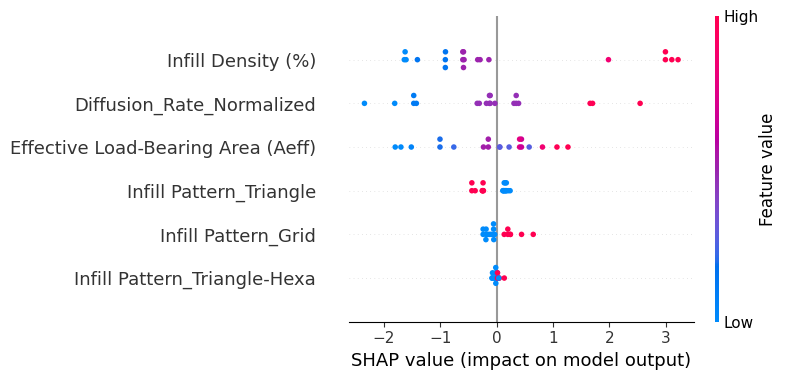

In [270]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(cat_physics)

# 2. Calculate SHAP values for your test set
# Use the actual physics features dataframe
shap_values = explainer.shap_values(X_test)

# 3. Plot the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES_PHYSICS)